#### Setup y Preparación

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from config import BRONZE_DIR
import matplotlib.dates as mdates

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

PARQUET_PATH = BRONZE_DIR / "rips_limpio.parquet"
con = duckdb.connect()

#### Serie Temporal Global: Atenciones Totales por Año

     Año  total_atenciones  n_registros
0   2009       103647922.0      1183667
1   2010       117239999.0      1274885
2   2011       147047328.0      1487434
3   2012       177694743.0      1616654
4   2013       145608545.0      1680044
5   2014       208540898.0      2009467
6   2015       194904245.0      1900852
7   2016       133987627.0      1723057
8   2017       211215369.0      2013316
9   2018       301590731.0      2245360
10  2019       309991292.0      2952548
11  2020       244751976.0      2529062
12  2021       233708510.0      2384496


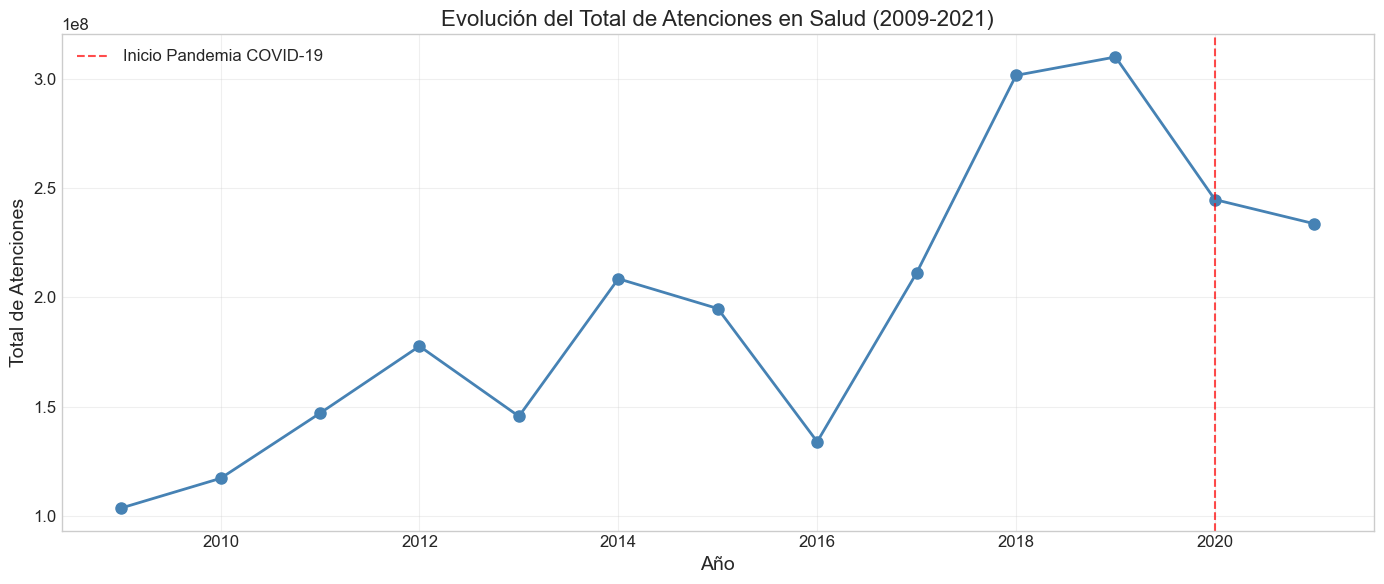

In [2]:
# Agregar por año
atenciones_anio = con.execute(f"""
    SELECT 
        Año,
        SUM(NumeroAtenciones) as total_atenciones,
        COUNT(*) as n_registros
    FROM '{PARQUET_PATH}'
    GROUP BY Año
    ORDER BY Año
""").fetchdf()

print(atenciones_anio)

# Gráfico de evolución
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(atenciones_anio['Año'], atenciones_anio['total_atenciones'], marker='o', linewidth=2, markersize=8, color='steelblue')
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Evolución del Total de Atenciones en Salud (2009-2021)', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Total de Atenciones', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_evolucion_atenciones.png', dpi=150, bbox_inches='tight')
plt.show()

#### Serie Temporal por Tipo de Atención

    Año             TipoAtencion  total_atenciones
0  2009                CONSULTAS        45458930.0
1  2009        HOSPITALIZACIONES          743772.0
2  2009  PROCEDIMIENTOS DE SALUD        55847224.0
3  2009                URGENCIAS         1597996.0
4  2010                CONSULTAS        44660894.0


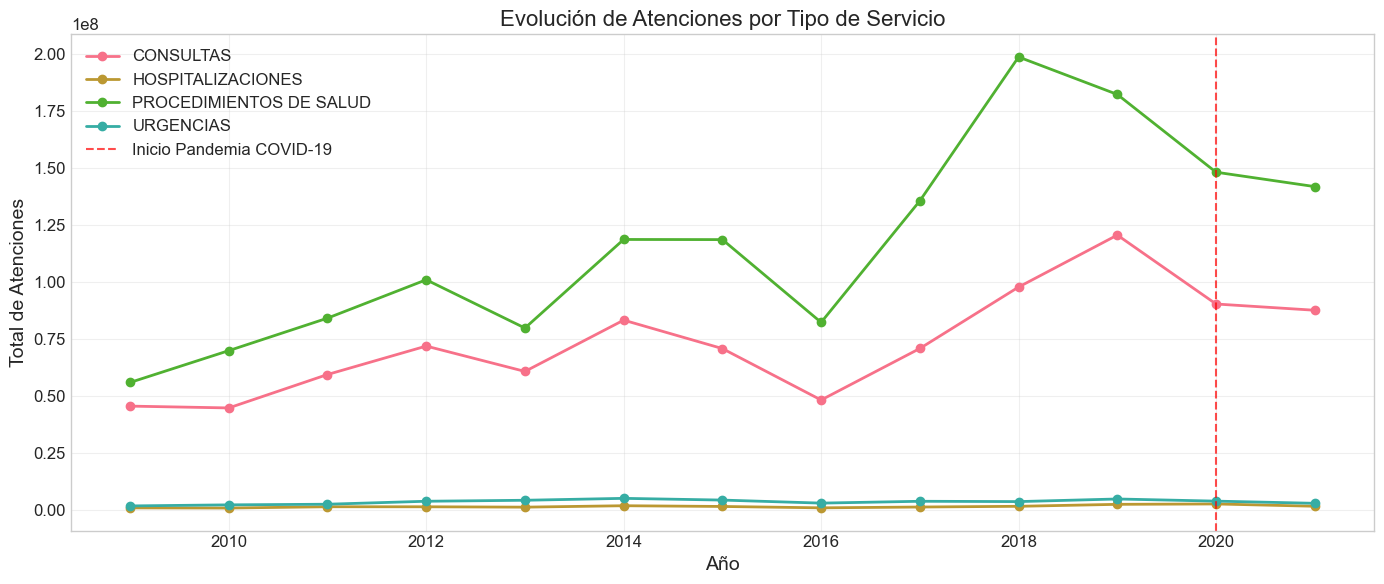

In [3]:
# Agregar por año y tipo
atenciones_anio_tipo = con.execute(f"""
    SELECT 
        Año,
        TipoAtencion,
        SUM(NumeroAtenciones) as total_atenciones
    FROM '{PARQUET_PATH}'
    GROUP BY Año, TipoAtencion
    ORDER BY Año, TipoAtencion
""").fetchdf()

print(atenciones_anio_tipo.head())

# Pivot para gráfico
pivot_tipo = atenciones_anio_tipo.pivot(index='Año', columns='TipoAtencion', values='total_atenciones')

# Gráfico de líneas por tipo
fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_tipo.columns:
    ax.plot(pivot_tipo.index, pivot_tipo[col], marker='o', label=col, linewidth=2)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Evolución de Atenciones por Tipo de Servicio', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Total de Atenciones', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_evolucion_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

#### Análisis del Outlier de Bogotá: Impacto en la Serie Temporal

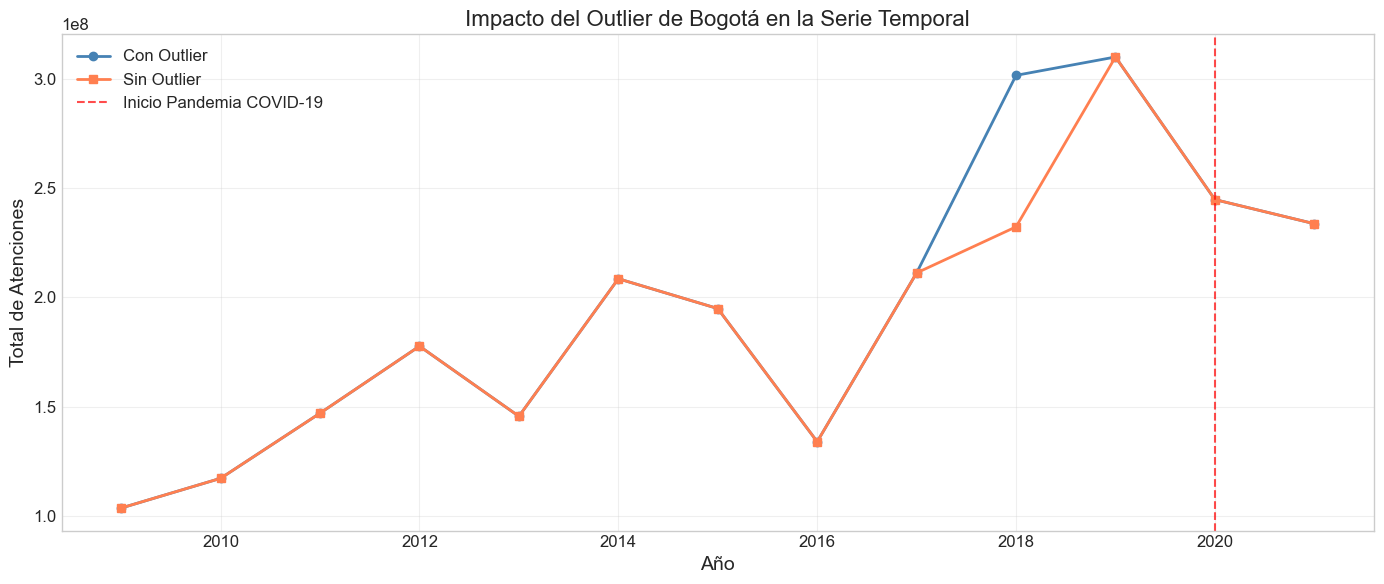

In [4]:
# Calcular el total sin el outlier de Bogotá (2018, PROCEDIMIENTOS, NO DEFINIDO)
atenciones_anio_sin_outlier = con.execute(f"""
    SELECT 
        Año,
        SUM(NumeroAtenciones) as total_atenciones
    FROM '{PARQUET_PATH}'
    WHERE NOT (Año = 2018 AND es_no_definido AND TipoAtencion = 'PROCEDIMIENTOS DE SALUD')
    GROUP BY Año
    ORDER BY Año
""").fetchdf()

# Comparar ambas series
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(atenciones_anio['Año'], atenciones_anio['total_atenciones'], 
        marker='o', label='Con Outlier', color='steelblue', linewidth=2)
ax.plot(atenciones_anio_sin_outlier['Año'], atenciones_anio_sin_outlier['total_atenciones'], 
        marker='s', label='Sin Outlier', color='coral', linewidth=2)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Impacto del Outlier de Bogotá en la Serie Temporal', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Total de Atenciones', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_impacto_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

#### Análisis de la Pandemia: Cambio de Tendencia

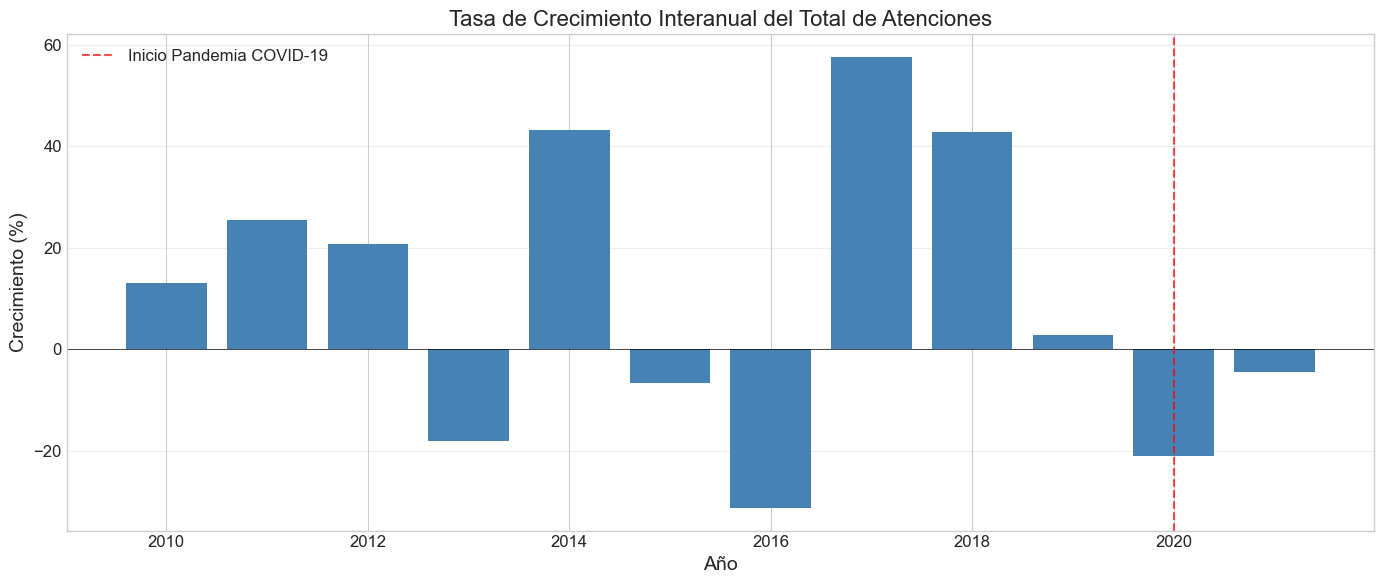

In [5]:
# Calcular crecimiento interanual
atenciones_anio['crecimiento_anual'] = atenciones_anio['total_atenciones'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(atenciones_anio['Año'][1:], atenciones_anio['crecimiento_anual'][1:], color='steelblue')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Tasa de Crecimiento Interanual del Total de Atenciones', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('Crecimiento (%)', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../reports/figures/04_crecimiento_anual.png', dpi=150, bbox_inches='tight')
plt.show()

#### Análisis del "NO DEFINIDO" en el Tiempo

     Año  atenciones_no_def  total_atenciones  pct_no_def
0   2009         32286560.0       103647922.0       31.15
1   2010         36498261.0       117239999.0       31.13
2   2011         43511250.0       147047328.0       29.59
3   2012         50668690.0       177694743.0       28.51
4   2013         37147991.0       145608545.0       25.51
5   2014         60165573.0       208540898.0       28.85
6   2015         56578300.0       194904245.0       29.03
7   2016         42508731.0       133987627.0       31.73
8   2017         59371734.0       211215369.0       28.11
9   2018         69303242.0       301590731.0       22.98
10  2019         68872670.0       309991292.0       22.22
11  2020         49666741.0       244751976.0       20.29
12  2021         48268658.0       233708510.0       20.65


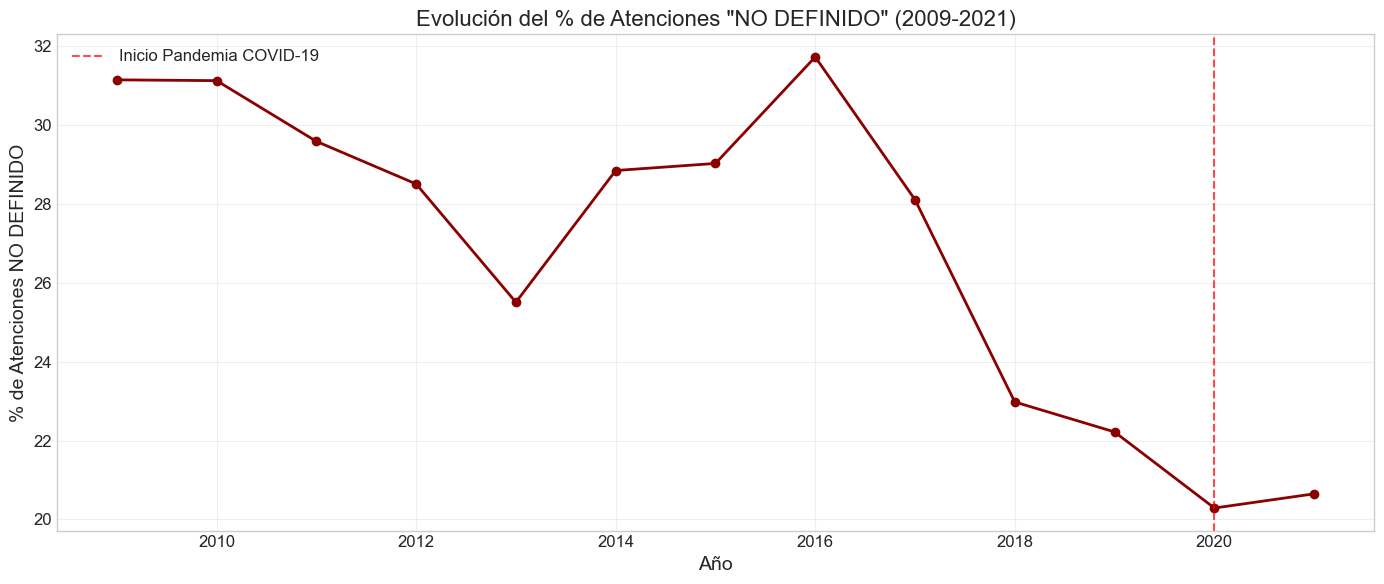

In [6]:
no_definido_anio = con.execute(f"""
    SELECT 
        Año,
        SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) as atenciones_no_def,
        SUM(NumeroAtenciones) as total_atenciones,
        ROUND((SUM(CASE WHEN es_no_definido THEN NumeroAtenciones ELSE 0 END) * 100.0 / SUM(NumeroAtenciones)), 2) as pct_no_def
    FROM '{PARQUET_PATH}'
    GROUP BY Año
    ORDER BY Año
""").fetchdf()

print(no_definido_anio)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(no_definido_anio['Año'], no_definido_anio['pct_no_def'], marker='o', linewidth=2, color='darkred')
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Inicio Pandemia COVID-19')
ax.set_title('Evolución del % de Atenciones "NO DEFINIDO" (2009-2021)', fontsize=16)
ax.set_xlabel('Año', fontsize=14)
ax.set_ylabel('% de Atenciones NO DEFINIDO', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/04_evolucion_no_definido.png', dpi=150, bbox_inches='tight')
plt.show()

#### Guardar Resultados

In [7]:
# Guardar todas las tablas de agregación para usarlas en el análisis espacial
atenciones_anio.to_csv('../reports/atenciones_por_anio.csv', index=False)
atenciones_anio_tipo.to_csv('../reports/atenciones_por_anio_tipo.csv', index=False)
no_definido_anio.to_csv('../reports/no_definido_por_anio.csv', index=False)

print("✅ Análisis temporal completado. Archivos guardados en reports/")

✅ Análisis temporal completado. Archivos guardados en reports/
